In [1]:
import model
import importlib
importlib.reload(model)
from model import DBM
import torch
import os

# log_dir = './runs/Mutations-bits:1-L:2-nh:[3600, 2500]-lr:0.01-momentum:0-bs:1000-gamma:0.001-epoch:1000-seed:0-0UAqFzWs'
# epoch = 360

model_path = 'models'
log_dir = './hpc_runs/unsupervised/bernoulli/Mutations-unsupervised-bernoulli-L:2-nh:[4900, 3600]-ySigma:1.0-rho:0.1-nMulti:100-lr:0.005-momentum:0.9-bs:1000-gamma:0.0001-epoch:1000-seed:0-0UAqFzWs'
epoch = 1000
dbm_model = DBM(nv=4801, nh=[4900, 3600], L=2)

checkpoint = torch.load(os.path.join(log_dir, model_path, f"model-{epoch}.pt"))
try:
    dbm_model.load_state_dict(checkpoint)
except RuntimeError as e:
    if 'module.' in list(checkpoint.keys())[0]:
        from collections import OrderedDict
        new_state_dict = OrderedDict((k.replace('module.', ''), v) for k, v in checkpoint.items())
        dbm_model.load_state_dict(new_state_dict)
    else:
        raise e
dbm_model.eval()

DBM(
  (weight): ParameterList(
      (0): Parameter containing: [torch.float32 of size 4900x4801]
      (1): Parameter containing: [torch.float32 of size 3600x4900]
  )
  (bias): ParameterList(
      (0): Parameter containing: [torch.float32 of size 4801]
      (1): Parameter containing: [torch.float32 of size 4900]
      (2): Parameter containing: [torch.float32 of size 3600]
  )
)

In [2]:
data = torch.load('cell_drug_response_samples.pt')
X = data['X']
y = data['y']

/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.Size([41531, 4801])


/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


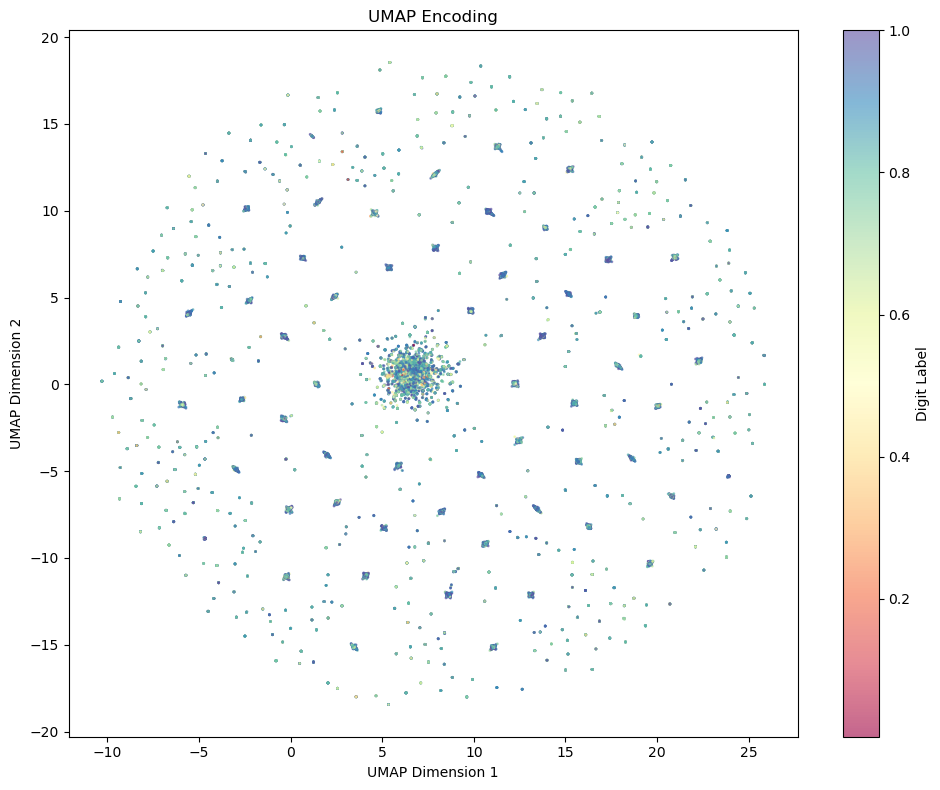

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP

X_np = X.numpy()
y_np = y.numpy()
print(X.shape)
umap = UMAP()
# umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
# Fit and transform the data
X_train_umap = umap.fit_transform(X_np)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y_np, cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()

In [4]:
from torch.utils.data import DataLoader, RandomSampler

dataset = torch.utils.data.TensorDataset(data['X'], data['y'])
dataloader = DataLoader(dataset, batch_size=1000, shuffle=False)
h_mode_list = []
h_rand_list = []
latent_logits_list = []

y_list = []
for x_batch, y_batch in dataloader:
    with torch.no_grad():
        h_mode, h_rand, latent_logits = dbm_model.encode(x_batch)
    h_mode_list.append(h_mode.numpy())
    h_rand_list.append(h_rand.numpy())
    latent_logits_list.append(latent_logits.numpy())
    y_list.append(y_batch.numpy())
h_mode_all = np.vstack(h_mode_list)
h_rand_all = np.vstack(h_rand_list)
latent_logits_all = np.vstack(latent_logits_list)
y_all = np.hstack(y_list)

In [5]:
h_mode_all.shape, h_rand_all.shape, y_all.shape

((41531, 3600), (41531, 3600), (41531,))

(41531, 3600)
(41531,)


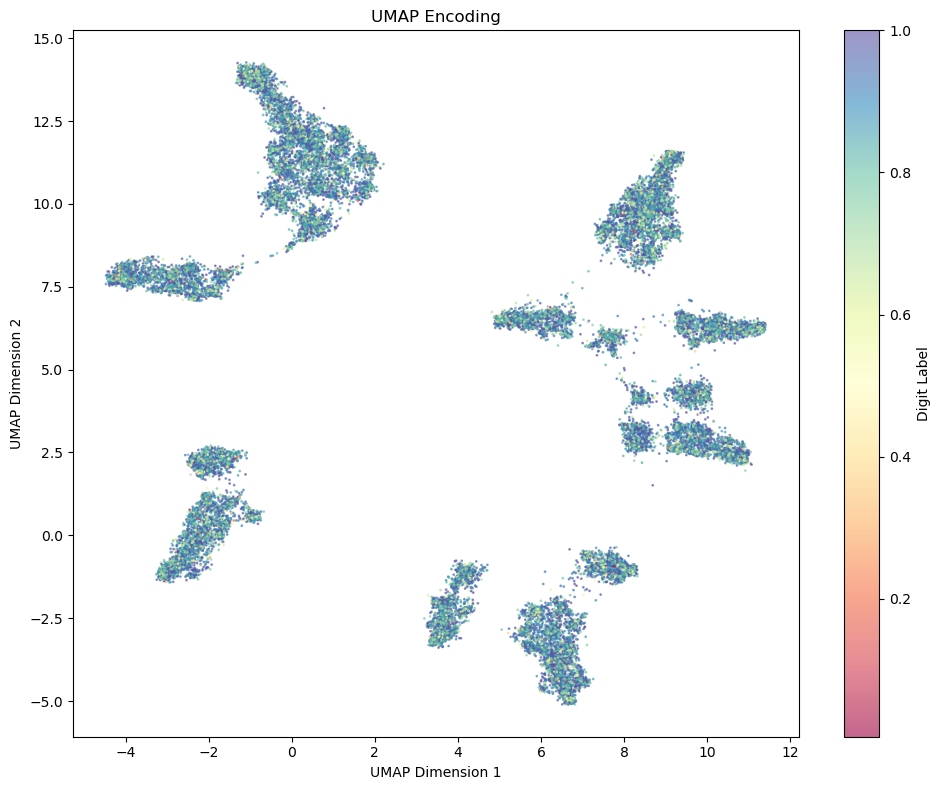

In [6]:
X_np = h_rand_all.squeeze()
y_np = y_all
print(X_np.shape)
print(y_np.shape)
umap = UMAP()
# umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
# Fit and transform the data
X_train_umap = umap.fit_transform(X_np)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y_np, cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()

(41531, 3600)
(41531,)


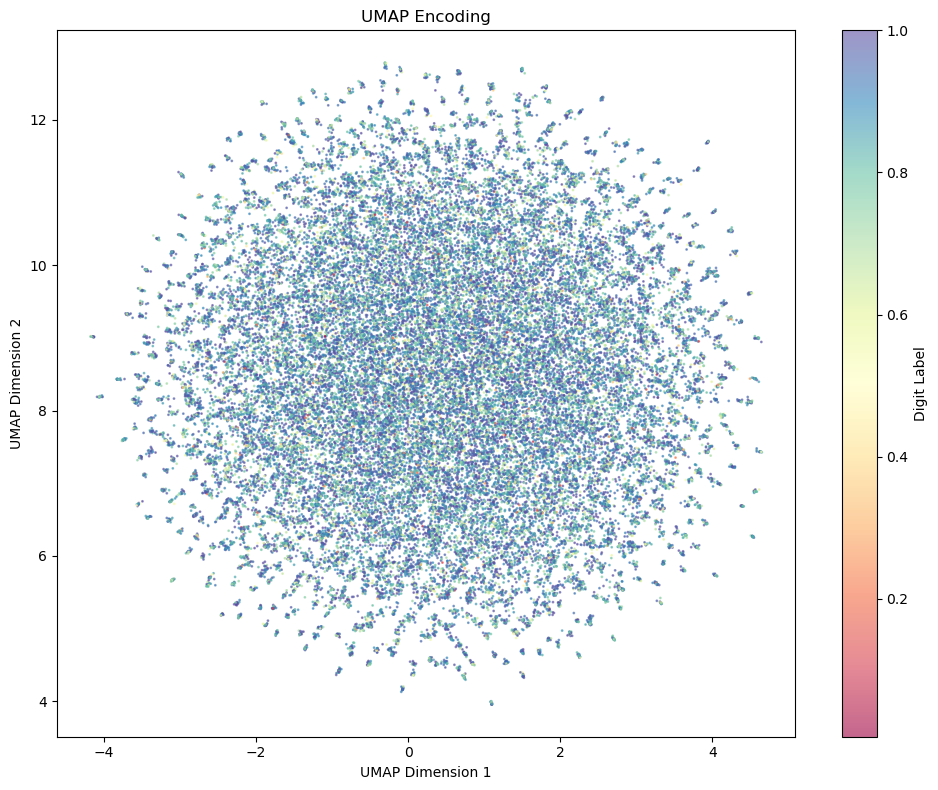

In [34]:
X_np = h_mode_all.squeeze()
y_np = y_all
print(X_np.shape)
print(y_np.shape)
umap = UMAP()
# umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
# Fit and transform the data
X_train_umap = umap.fit_transform(X_np)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y_np, cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()

torch.Size([10000, 10000])
(10000, 3600)
(10000,)


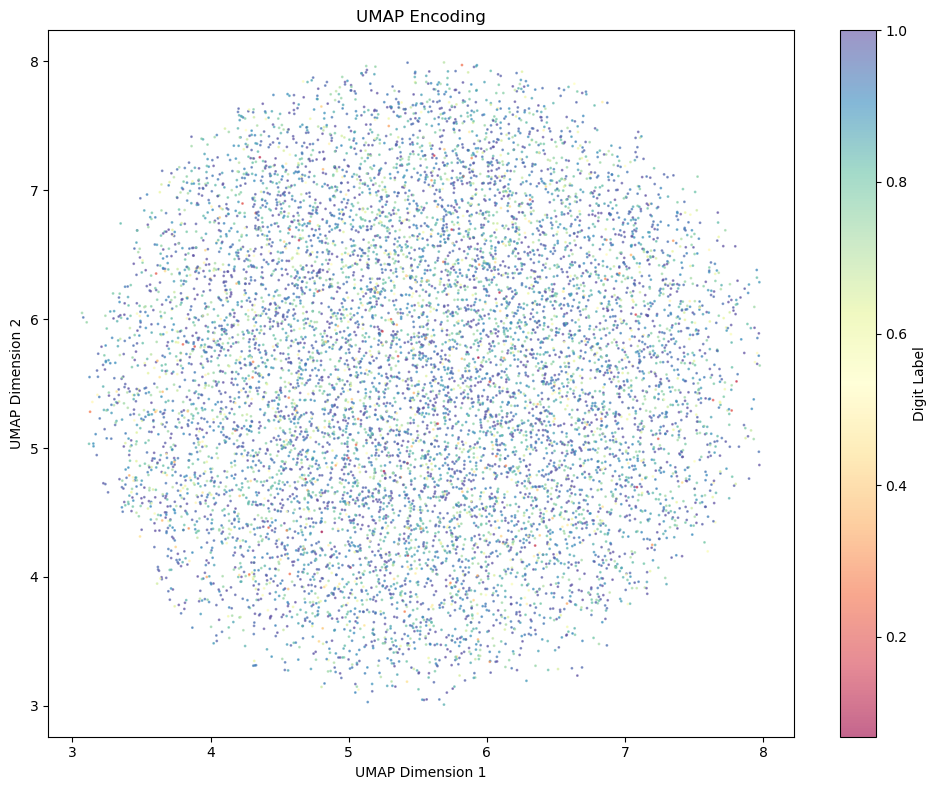

In [33]:
import torch

sample_size = 10000
rng = np.random.default_rng(42)
idx = rng.choice(len(X), size=sample_size, replace=False)
latent_logits_slice = torch.from_numpy(latent_logits_all[idx])
bernoulli_latent = h_rand_all[idx].squeeze()
label_slice = torch.from_numpy(y_all[idx])

# Convert logits to probabilities
probs_slice = torch.nn.functional.softmax(latent_logits_slice, dim=1)

# Sample one index per row
M = 10000
N, D = probs_slice.shape

# Sample all at once
samples = torch.multinomial(probs_slice, num_samples=M, replacement=True)
print(samples.shape)
aggregated_samples = torch.stack([torch.bincount(samples[i], minlength=D).to(torch.float32)/M for i in range(N)])

# one_hot_samples = torch.nn.functional.one_hot(samples, num_classes=D)  # (N, M, D)

# dataset = (one_hot_samples, label_slice)
X_np = aggregated_samples.numpy()
# y_np = dataset[1].detach().numpy()
y_np = y_all[idx]
print(X_np.shape)
print(y_np.shape)
umap = UMAP()
# umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
# Fit and transform the data
X_train_umap = umap.fit_transform(X_np)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y_np, cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()

(100, 3600)
(100,)


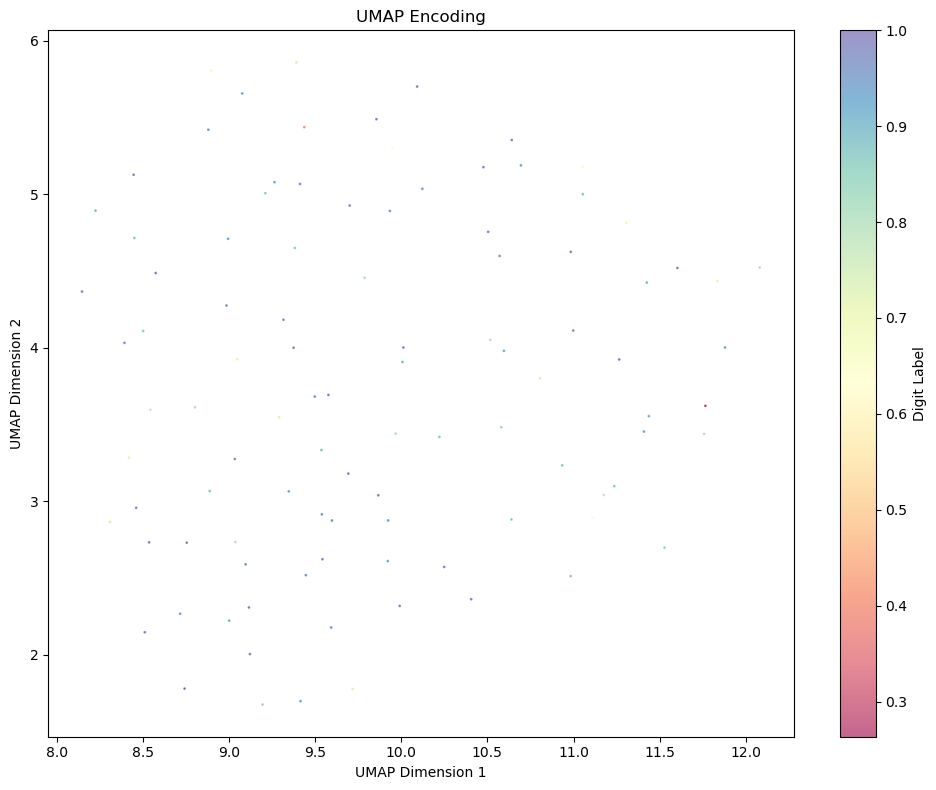

(500, 3600)
(500,)


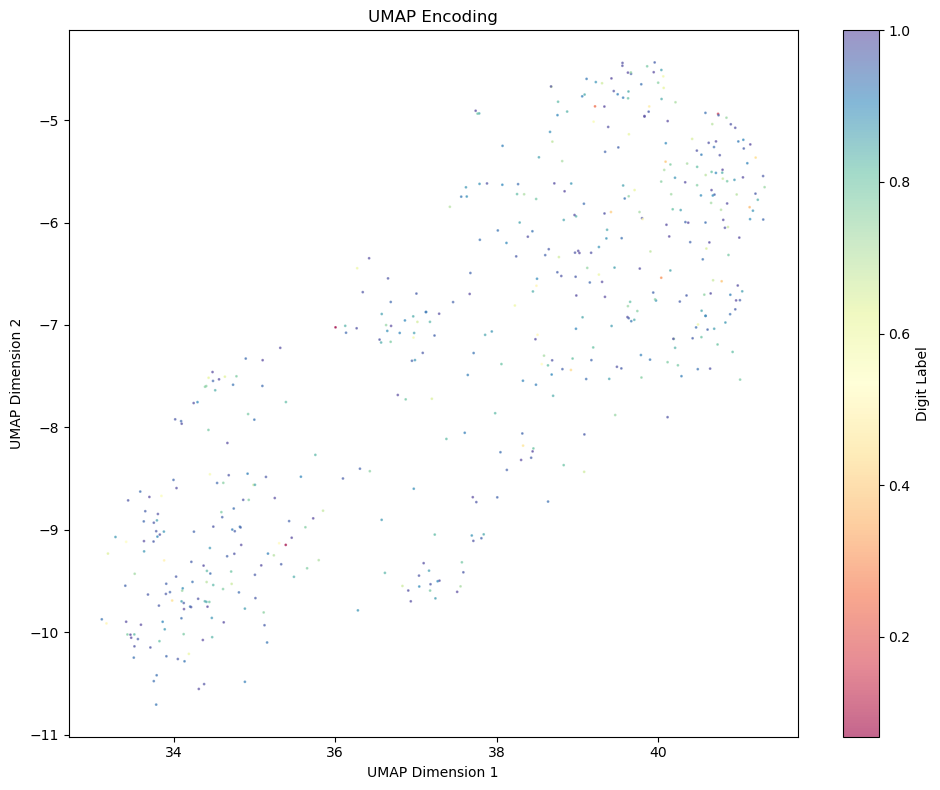

(1000, 3600)
(1000,)


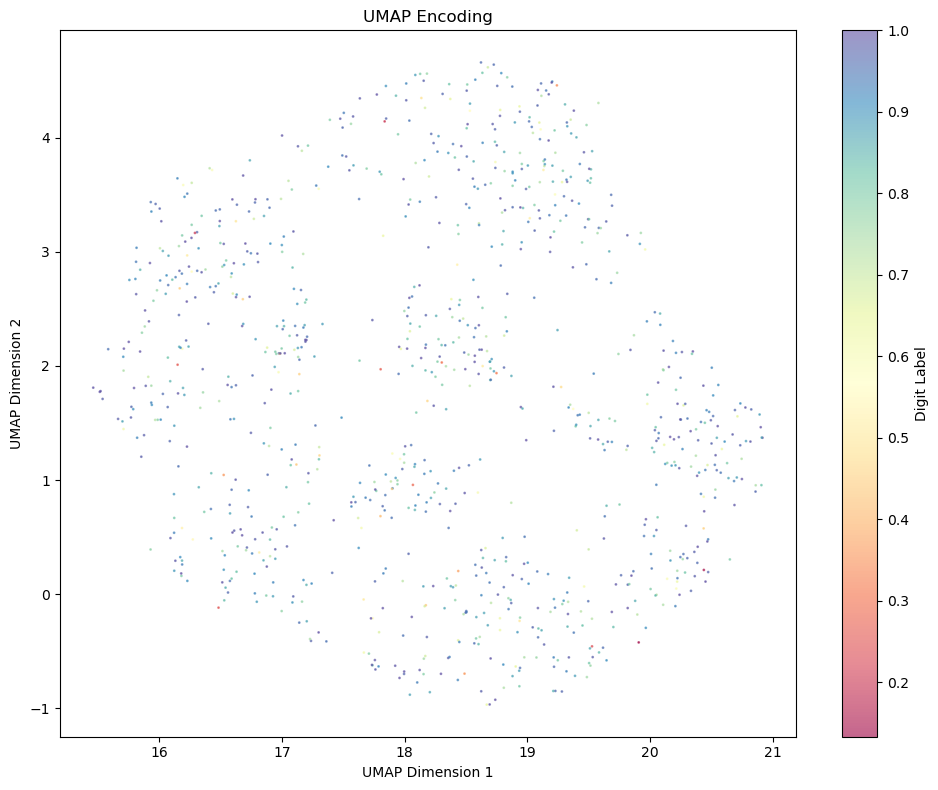

(5000, 3600)
(5000,)


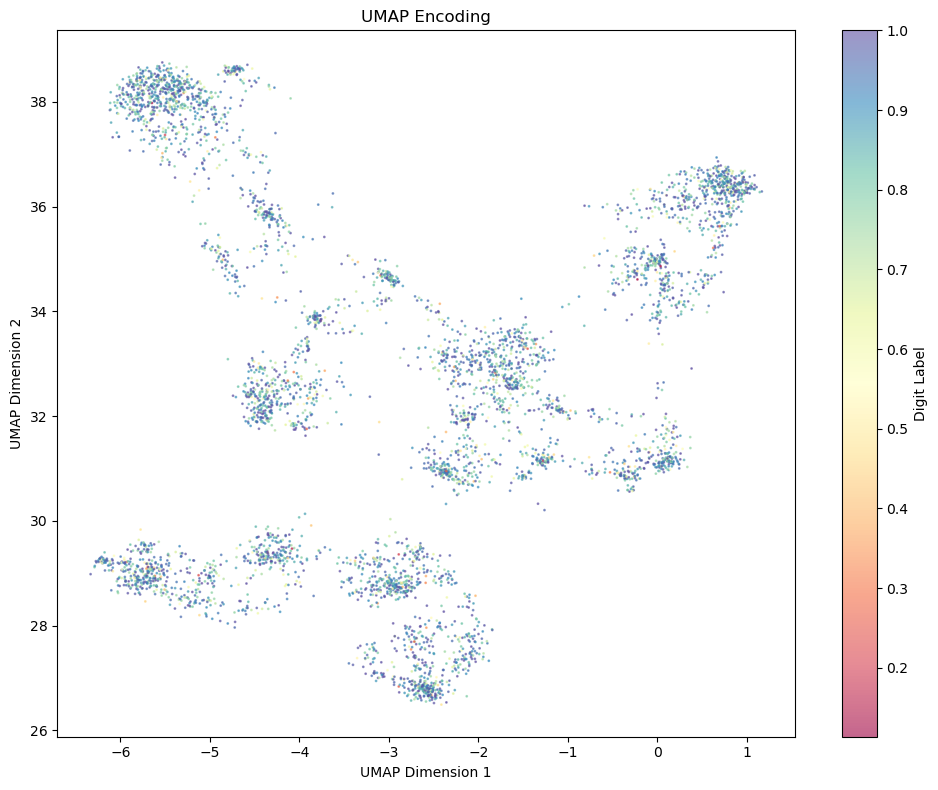

(10000, 3600)
(10000,)


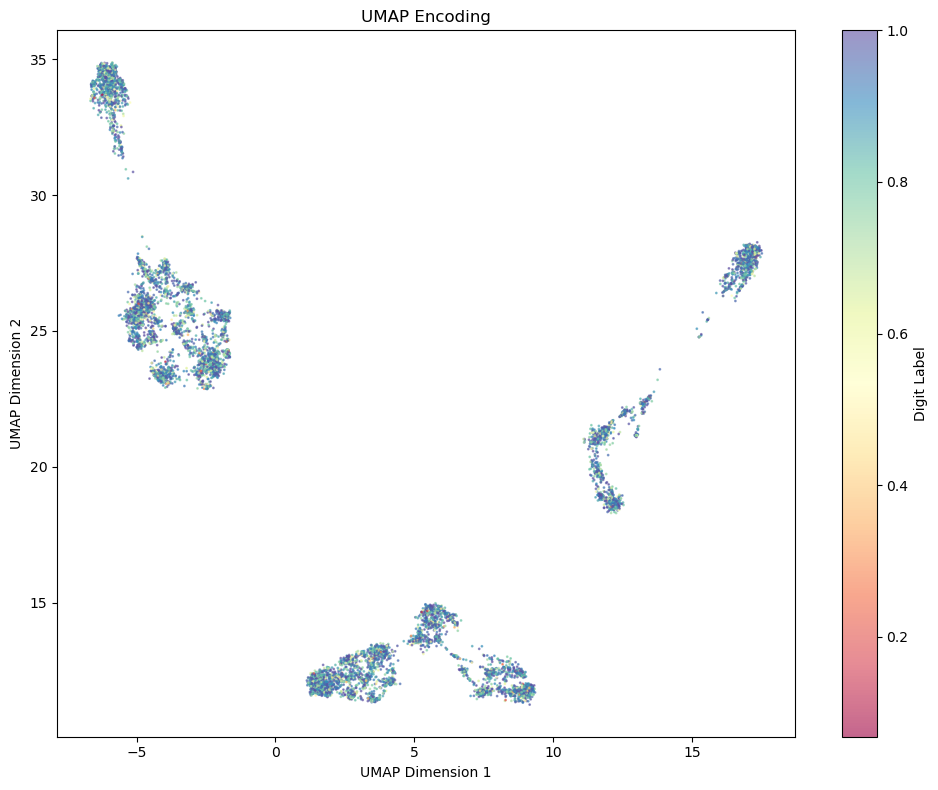

In [28]:
# X_np = dataset[0].detach().numpy().sum(axis=1)
for sample_size in [100, 500, 1000, 5000, 10000]:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X), size=sample_size, replace=False)
    X_np = h_rand_all[idx].squeeze()
    # y_np = dataset[1].detach().numpy()
    y_np = y_all[idx]
    print(X_np.shape)
    print(y_np.shape)
    umap = UMAP()
    # umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
    # Fit and transform the data
    X_train_umap = umap.fit_transform(X_np)

    # Plot the results
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y_np, cmap="Spectral", s=1, alpha=0.6)
    plt.colorbar(scatter, label="Digit Label")
    plt.title("UMAP Encoding")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    # Show the plot
    plt.tight_layout()
    plt.show()

In [ ]:
dataset[0].shape, dataset[1].shape

(torch.Size([100, 10000, 3600]), torch.Size([100]))

: 

In [ ]:
# import hdmm_torch
# from nbimporter import NotebookLoader
# import nbimporter
# import torch_hdmm_test
# importlib.reload(torch_hdmm_test)
# from torch_hdmm_test import data_summary
# importlib.reload(hdmm_torch)
# from hdmm_torch import HDMM


# vocab_size = D
# struct_upbd = {"G0": 20, "G1": 10, "G2": 5}
# for seed in range(0, 110, 10):
#     log_dir = f"./logs/seed_{seed}"
#     model = HDMM(struct_upbd, vocab_size=vocab_size, device='cpu', seed=seed)
#     print("Model initialized.")

#     z_gen, z_reg, local_category_assignments, doc_values, log_prob = model.infer(dataset[0].to(torch.float32), reg=dataset[1].to(torch.float32), num_iters=300, sanity_check=False, plot_gap=300, log_dir=log_dir)
#     print("Inference completed.")

#     post_state = {
#         "struct_params": model.struct_params,
#         "struct_values": model.SV,
#         "mixture_components": {
#             "generation": model.mixture_components["generation"],
#             "regression_mu": model.mixture_components["regression_mu"],
#             "regression_sigma": model.mixture_components["regression_sigma"],
#         },
#         "local_category_assignments": local_category_assignments,
#         "doc_values": None,
#         "words": {
#             "z_gen": z_gen,
#             "z_reg": z_reg,
#             "obs": dataset[0],
#             "reg": dataset[1],
#         },
#     }
#     model_return = (post_state, None)
#     data_summary(model_return, {"x": dataset[0], "y": dataset[1]}, struct_upbd, log_dir=log_dir)

Model initialized.


Gibbs Sampling:   0%|          | 0/300 [00:00<?, ?it/s]